In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../dataset/credit_card_fraud_10k.csv")

In [3]:
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [4]:
df.shape

(10000, 10)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  str    
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), str(1)
memory usage: 781.4 KB


In [6]:
df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


In [7]:
df.isnull().sum()

transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

# Observation

- Missing values were checked.
- If no missing values are found, the dataset is ready for preprocessing.

In [8]:
df.duplicated().sum()

np.int64(0)

# Observation

- Duplicate records were checked.
- Duplicate records, if present, should be removed before model training.

In [10]:
df.columns

Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='str')

In [11]:
df["is_fraud"].value_counts()

is_fraud
0    9849
1     151
Name: count, dtype: int64

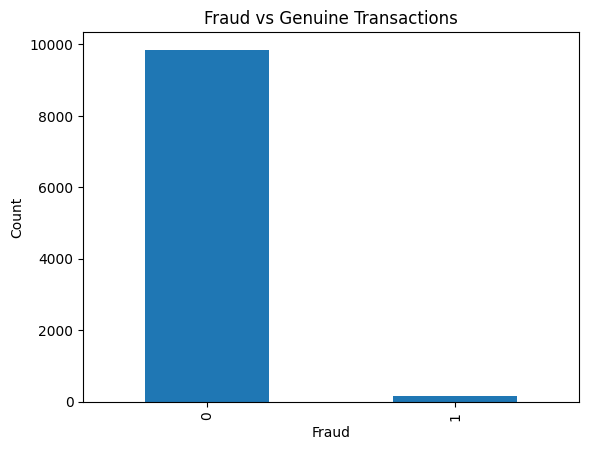

In [13]:
df["is_fraud"].value_counts().plot(kind="bar")

plt.title("Fraud vs Genuine Transactions")
plt.xlabel("Fraud")
plt.ylabel("Count")

plt.show()

# Observation

- The graph shows the distribution of genuine and fraudulent transactions.
- Usually, fraud datasets are highly imbalanced because fraudulent transactions are much fewer than genuine ones.

In [15]:
df.corr(numeric_only=True)

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
transaction_id,1.000000,-0.017676,-0.020081,-0.003746,0.003599,0.012292,-0.013903,0.005412,-0.010155
amount,-0.017676,1.000000,-0.007369,0.004094,0.004232,0.009698,-0.001133,0.012735,0.028404
transaction_hour,-0.020081,-0.007369,1.000000,-0.000255,0.004776,0.004054,-0.003709,0.012198,-0.138665
foreign_transaction,-0.003746,0.004094,-0.000255,1.000000,0.001426,0.012780,-0.007686,0.005408,0.185597
location_mismatch,0.003599,0.004232,0.004776,0.001426,1.000000,0.002217,-0.005892,0.010049,0.173009
device_trust_score,0.012292,0.009698,0.004054,0.012780,0.002217,1.000000,-0.000095,0.013717,-0.137913
velocity_last_24h,-0.013903,-0.001133,-0.003709,-0.007686,-0.005892,-0.000095,1.000000,-0.003970,0.103413
cardholder_age,0.005412,0.012735,0.012198,0.005408,0.010049,0.013717,-0.003970,1.000000,-0.000590
is_fraud,-0.010155,0.028404,-0.138665,0.185597,0.173009,-0.137913,0.103413,-0.000590,1.000000


In [18]:
correlation = df.select_dtypes(include=['number']).corr()
correlation

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
transaction_id,1.000000,-0.017676,-0.020081,-0.003746,0.003599,0.012292,-0.013903,0.005412,-0.010155
amount,-0.017676,1.000000,-0.007369,0.004094,0.004232,0.009698,-0.001133,0.012735,0.028404
transaction_hour,-0.020081,-0.007369,1.000000,-0.000255,0.004776,0.004054,-0.003709,0.012198,-0.138665
foreign_transaction,-0.003746,0.004094,-0.000255,1.000000,0.001426,0.012780,-0.007686,0.005408,0.185597
location_mismatch,0.003599,0.004232,0.004776,0.001426,1.000000,0.002217,-0.005892,0.010049,0.173009
device_trust_score,0.012292,0.009698,0.004054,0.012780,0.002217,1.000000,-0.000095,0.013717,-0.137913
velocity_last_24h,-0.013903,-0.001133,-0.003709,-0.007686,-0.005892,-0.000095,1.000000,-0.003970,0.103413
cardholder_age,0.005412,0.012735,0.012198,0.005408,0.010049,0.013717,-0.003970,1.000000,-0.000590
is_fraud,-0.010155,0.028404,-0.138665,0.185597,0.173009,-0.137913,0.103413,-0.000590,1.000000


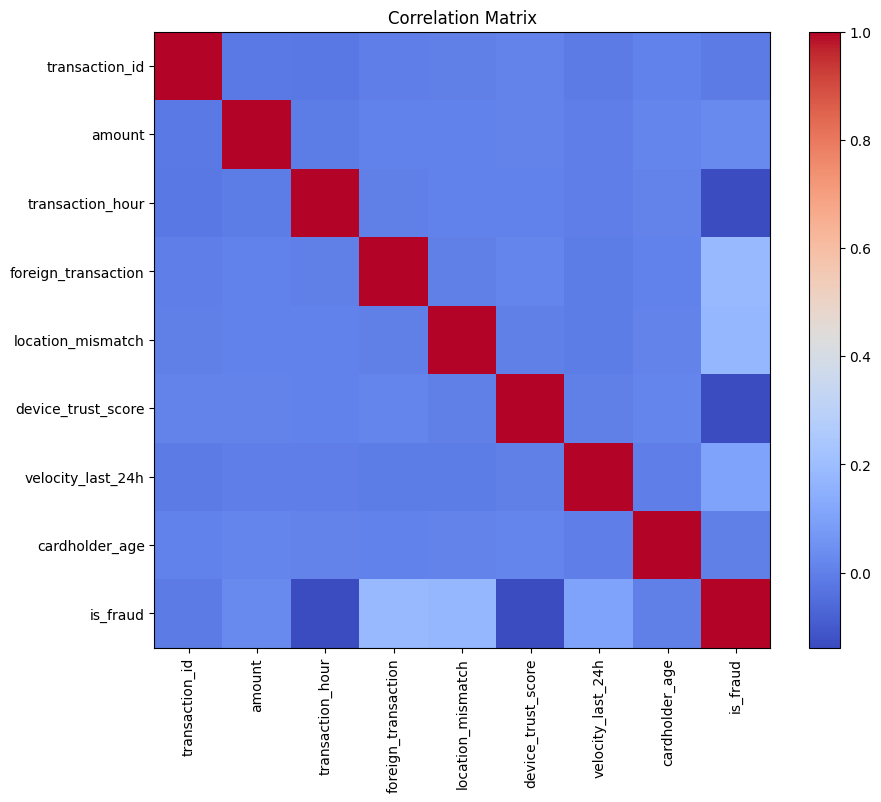

In [19]:
import matplotlib.pyplot as plt

correlation = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10,8))
plt.imshow(correlation, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title("Correlation Matrix")
plt.show()

# Observation


- Most features have a weak correlation with each other.
- The target variable (**is_fraud**) has a moderate relationship with a few features.
- The dataset is suitable for training a machine learning model.

In [21]:
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["merchant_category"] = le.fit_transform(df["merchant_category"])

In [27]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
# Train the Model

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

c:\Users\Pc\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [29]:
y_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.991


In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1967    2]
 [  16   15]]


In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1969
           1       0.88      0.48      0.62        31

    accuracy                           0.99      2000
   macro avg       0.94      0.74      0.81      2000
weighted avg       0.99      0.99      0.99      2000



## Conclusion

- Built a Logistic Regression model for fraud detection.
- Achieved high accuracy (~99%).
- Model performs well but struggles slightly with minority class (fraud cases).
- This shows the impact of class imbalance in real-world datasets.